# Filter Methods

Filter Methods are feature selection techniques that select features
using statistical properties of the data.

They evaluate the relationship between features and the target without
training a machine learning model.

Filter methods are usually:

- Fast
- Simple
- Computationally efficient
- Suitable for high-dimensional datasets

Common Filter Methods include:

- Variance Threshold
- Correlation
- Chi-Square Test
- ANOVA
- Mutual Information

## How Filter Methods Work

The general process is:

1. Calculate a statistical score for each feature.
2. Measure how useful the feature is.
3. Rank the features according to their scores.
4. Select the best features.
5. Remove weak or irrelevant features.

The machine learning model is not involved during the selection process.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    "Age": np.random.randint(18, 60, 200),
    "Income": np.random.randint(20000, 100000, 200),
    "Experience": np.random.randint(0, 20, 200),
    "Random_Feature": np.random.randn(200),
    "Target": np.random.randint(0, 2, 200)
})

df.head()

,Age,Income,Experience,Random_Feature,Target
0,56,45342,6,-0.110932,1
1,46,57157,4,0.976309,0
2,32,87863,2,-1.452849,0
3,25,72083,11,0.784006,0
4,38,85733,15,-0.157724,0


## 1. Variance Threshold

Variance measures how much a feature changes across observations.

If a feature has very low variance, it contains almost the same value
for every observation.

Such a feature may provide little useful information.

Variance Threshold removes features whose variance is below a specified
threshold.

In [2]:
from sklearn.feature_selection import VarianceThreshold

X = df.drop(columns="Target")

selector = VarianceThreshold(threshold=0)

X_selected = selector.fit_transform(X)

X_selected.shape

(200, 4)

### Important

Variance Threshold does not look at the target variable.

It only checks the variance of each feature.

## 2. Correlation

Correlation measures the relationship between two numerical variables.

Pearson correlation ranges from:

- -1 → Perfect negative relationship
- 0 → No linear relationship
- +1 → Perfect positive relationship

Highly correlated features may contain redundant information.

For example:

Height in centimeters
Height in meters

contain almost the same information.

Keeping both may be unnecessary.

In [3]:
correlation = df.corr(numeric_only=True)

correlation

,Age,Income,Experience,Random_Feature,Target
Age,1.000000,0.032561,-0.066043,-0.037677,-0.012390
Income,0.032561,1.000000,-0.044615,0.079769,0.065456
Experience,-0.066043,-0.044615,1.000000,0.070641,-0.008484
Random_Feature,-0.037677,0.079769,0.070641,1.000000,-0.069611
Target,-0.012390,0.065456,-0.008484,-0.069611,1.000000


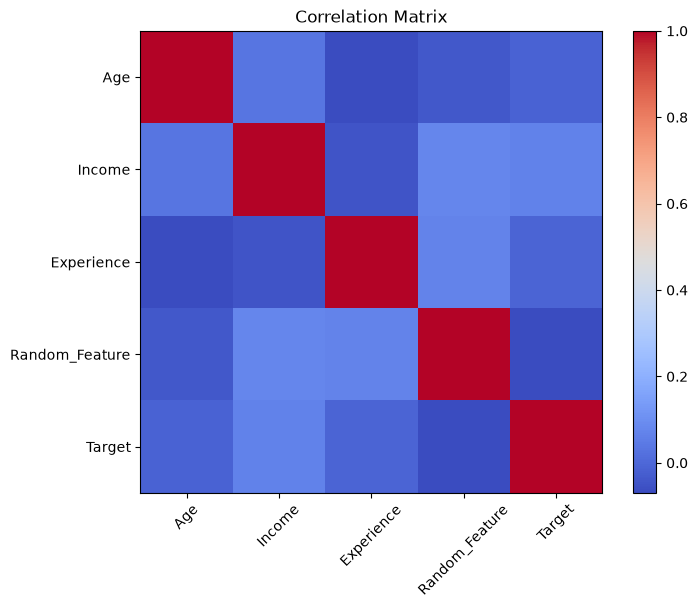

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap="coolwarm")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")
plt.show()

### Removing Highly Correlated Features

If two features have a very high correlation, we may remove one of them
to reduce redundancy.

A common threshold is:

|Correlation| > 0.90

However, the appropriate threshold depends on the dataset and problem.

## 3. Chi-Square Test

The Chi-Square test is commonly used to measure the relationship between:

Categorical Features → Categorical Target

It tests whether two categorical variables are independent.

A high Chi-Square score indicates a stronger relationship between the
feature and the target.

The feature values must be non-negative for sklearn's Chi-Square selector.

In [5]:
from sklearn.feature_selection import chi2

X = df[["Age", "Income", "Experience"]]
y = df["Target"]

chi_scores, p_values = chi2(X, y)

chi_results = pd.DataFrame({
    "Feature": X.columns,
    "Chi2_Score": chi_scores,
    "P_Value": p_values
})

chi_results

,Feature,Chi2_Score,P_Value
0,Age,0.125530,0.723112
1,Income,8212.671346,0.000000
2,Experience,0.049786,0.823435


### Interpretation

Chi-Square Score:

Higher score → Stronger relationship with target

P-value:

Lower p-value → Stronger evidence of a relationship

A common significance level is:

α = 0.05

If:

p-value < 0.05

the relationship is considered statistically significant.

## Selecting the Best Features with Chi-Square

`SelectKBest` can select the top K features according to a statistical
test.

Here we use the Chi-Square test.

In [6]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(
    score_func=chi2,
    k=2
)

X_selected = selector.fit_transform(X, y)

X_selected.shape

(200, 2)

In [7]:
selected_features = X.columns[
    selector.get_support()
]

selected_features

Index(['Age', 'Income'], dtype='str')

## 4. ANOVA F-Test

ANOVA stands for Analysis of Variance.

The ANOVA F-test is commonly used when:

Numerical Feature → Categorical Target

It checks whether the mean values of a numerical feature differ
significantly across target groups.

A higher F-score generally indicates a stronger relationship with
the target.

In [8]:
from sklearn.feature_selection import f_classif

X = df.drop(columns="Target")
y = df["Target"]

f_scores, p_values = f_classif(X, y)

anova_results = pd.DataFrame({
    "Feature": X.columns,
    "F_Score": f_scores,
    "P_Value": p_values
})

anova_results

,Feature,F_Score,P_Value
0,Age,0.030401,0.861762
1,Income,0.851984,0.357115
2,Experience,0.014254,0.905087
3,Random_Feature,0.964131,0.327346


In [9]:
selector = SelectKBest(
    score_func=f_classif,
    k=2
)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[
    selector.get_support()
]

selected_features

Index(['Income', 'Random_Feature'], dtype='str')

## 5. Mutual Information

Mutual Information measures how much information one variable provides
about another variable.

It can detect both:

- Linear relationships
- Non-linear relationships

A higher Mutual Information score means that the feature provides more
information about the target.

Unlike simple correlation, Mutual Information can detect more complex
relationships.

In [10]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop(columns="Target")
y = df["Target"]

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information": mi_scores
})

mi_results.sort_values(
    "Mutual_Information",
    ascending=False
)

,Feature,Mutual_Information
0,Age,0.040287
1,Income,0.000000
2,Experience,0.000000
3,Random_Feature,0.000000


In [11]:
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=2
)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[
    selector.get_support()
]

selected_features

Index(['Age', 'Random_Feature'], dtype='str')